# Week 5b — Wikipedia pageviews (summary) analysis

This notebook walks through a **standard first pass** on **`design_trends.csv`**: one row per Wikipedia article from the script’s ranked list, with totals, averages, momentum, and LCD strings.

**Before you start:** from this folder (`week 5/week 5b/`), run `python design_trends.py` once so **`design_trends.csv`** is current.

---

1. What does your dataset look like? `head()` / `info()`  
2. What is the distribution of the most important numeric column?  
3. Filter to a meaningful subset — what is in it?  
4. Group by a category and take the mean of a numeric column.  
5. Where are missing values? Are any columns incomplete?


## Setup

In [4]:
from pathlib import Path

import pandas as pd

DATA_DIR = Path(".")
TRENDS_CSV = DATA_DIR / "design_trends.csv"

assert TRENDS_CSV.is_file(), (
    f"Missing {TRENDS_CSV.resolve()}. Run: python design_trends.py"
)

print("pandas:", pd.__version__)

pandas: 3.0.2


---
## 1. What does your dataset look like? `head()` and `info()`

Load **`design_trends.csv`**, peek at the first and last rows, then inspect dtypes and non-null counts.

In [5]:
df = pd.read_csv(TRENDS_CSV, encoding="utf-8")
assert "total_views_in_window" in df.columns and "trend" in df.columns, (
    "Expected design_trends.csv from design_trends.py (summary by article)."
)

df.head(10)

,rank,trend,window_start,window_end,days_with_data,total_views_in_window,avg_views_per_day,est_views_per_month,peak_date,peak_views,peak_to_mean_daily_ratio,recent_30d_avg_views,prior_30d_avg_views,pct_change_recent_vs_prior_30d,momentum,trend_status,lcd_line1,lcd_line2
0,1,BonziBuddy,2026-01-29,2026-04-29,91,46774,514.00,15644.6,2026-02-26,948,1.84,486.00,580.67,-16.3,Fading,fading,BonziBuddy,Status: Fading
1,2,Brain–computer interface,2026-01-29,2026-04-29,91,40392,443.87,13510.0,2026-02-09,598,1.35,399.03,458.57,-13.0,Fading,fading,Brain–computer i,Status: Fading
2,3,Human–computer interaction,2026-01-29,2026-04-29,91,22294,244.99,7456.7,2026-02-27,336,1.37,231.93,238.03,-2.6,Peaked / Stable,peaked_or_stable,Human–computer i,Status: Peaked /
3,4,Center for Humane Technology,2026-01-29,2026-04-29,91,9044,99.38,3025.0,2026-03-22,457,4.60,115.03,117.83,-2.4,Peaked / Stable,peaked_or_stable,Center for Human,Status: Peaked /
4,5,As We May Think,2026-01-29,2026-04-29,90,7793,86.59,2635.5,2026-02-28,275,3.18,79.73,91.20,-12.6,Fading,fading,As We May Think,Status: Fading
5,6,Bad Day (viral video),2026-01-29,2026-04-29,91,6358,69.87,2126.6,2026-04-29,1109,15.87,103.37,51.63,100.2,Rising,rising,Bad Day (viral v,Status: Rising
6,7,10-foot user interface,2026-01-29,2026-04-29,91,3948,43.38,1320.5,2026-02-02,68,1.57,40.73,42.20,-3.5,Peaked / Stable,peaked_or_stable,10-foot user int,Status: Peaked /
7,8,Computers are social actors,2026-01-29,2026-04-29,91,3389,37.24,1133.5,2026-04-27,70,1.88,38.40,38.00,1.1,Peaked / Stable,peaked_or_stable,Computers are so,Status: Peaked /
8,9,Conference on Human Factors in Computing Systems,2026-01-29,2026-04-29,91,3266,35.89,1092.4,2026-04-13,76,2.12,39.77,33.70,18.0,Rising,rising,Conference on Hu,Status: Rising
9,10,Addiction by Design,2026-01-29,2026-04-29,91,2791,30.67,933.5,2026-02-10,104,3.39,30.90,25.97,19.0,Rising,rising,Addiction by Des,Status: Rising


In [6]:
df.tail(8)

,rank,trend,window_start,window_end,days_with_data,total_views_in_window,avg_views_per_day,est_views_per_month,peak_date,peak_views,peak_to_mean_daily_ratio,recent_30d_avg_views,prior_30d_avg_views,pct_change_recent_vs_prior_30d,momentum,trend_status,lcd_line1,lcd_line2
42,43,Brain painting,2026-01-29,2026-04-29,89,201,2.26,68.7,2026-03-26,8,3.54,2.33,2.40,-2.8,Peaked / Stable,peaked_or_stable,Brain painting,Status: Peaked /
43,44,Confederate effect,2026-01-29,2026-04-29,89,170,1.91,58.1,2026-04-21,10,5.24,1.90,1.53,23.9,Rising,rising,Confederate effe,Status: Rising
44,45,Ben Bederson,2026-01-29,2026-04-29,88,164,1.86,56.7,2026-02-02,7,3.76,1.67,1.53,8.7,Peaked / Stable,peaked_or_stable,Ben Bederson,Status: Peaked /
45,46,Computer Graphics International,2026-01-29,2026-04-29,87,136,1.56,47.6,2026-03-04,9,5.76,1.73,1.70,2.0,Peaked / Stable,peaked_or_stable,Computer Graphic,Status: Peaked /
46,47,CMN-GOMS,2026-01-29,2026-04-29,86,115,1.34,40.7,2026-01-30,9,6.73,1.17,1.30,-10.3,Fading,fading,CMN-GOMS,Status: Fading
47,48,Alerting system,2026-01-29,2026-04-29,79,89,1.13,34.3,2026-02-17,5,4.44,1.33,0.83,60.0,Rising,rising,Alerting system,Status: Rising
48,49,Barrier pointing,2026-01-29,2026-04-29,84,86,1.02,31.2,2026-03-15,7,6.84,0.77,1.43,-46.5,Fading,fading,Barrier pointing,Status: Fading
49,50,Cognitive infocommunications,2026-01-29,2026-04-29,84,78,0.93,28.3,2026-03-31,9,9.69,0.93,1.07,-12.5,Fading,fading,Cognitive infoco,Status: Fading


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   rank                            50 non-null     int64  
 1   trend                           50 non-null     str    
 2   window_start                    50 non-null     str    
 3   window_end                      50 non-null     str    
 4   days_with_data                  50 non-null     int64  
 5   total_views_in_window           50 non-null     int64  
 6   avg_views_per_day               50 non-null     float64
 7   est_views_per_month             50 non-null     float64
 8   peak_date                       50 non-null     str    
 9   peak_views                      50 non-null     int64  
 10  peak_to_mean_daily_ratio        50 non-null     float64
 11  recent_30d_avg_views            50 non-null     float64
 12  prior_30d_avg_views             50 non-null     f

---
## 2. Distribution of the most important column

For comparing **overall interest** across articles in this table, the main numeric column is **`total_views_in_window`** (sum of daily pageviews in the analysis window). **`avg_views_per_day`** is another good choice; here we focus on totals.

We use `describe()` plus a histogram of **`total_views_in_window`**.

In [9]:
df["total_views_in_window"].describe()

count       50.000000
mean      3690.740000
std       8955.294316
min         78.000000
25%        358.250000
50%       1122.500000
75%       2669.500000
max      46774.000000
Name: total_views_in_window, dtype: float64

Text(0.5, 0, 'total_views_in_window')

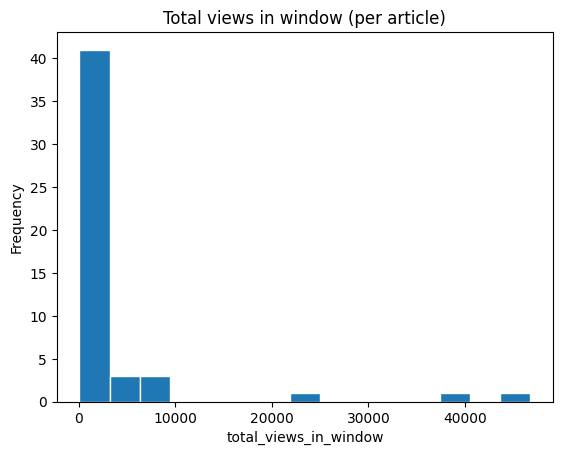

In [13]:
ax = df["total_views_in_window"].plot.hist(
    bins=15,
    edgecolor="white",
    title="Total views in window (per article)",
)
ax.set_xlabel("total_views_in_window")

---
## 3. Filter to a meaningful subset — what is in it?

Example subset: articles whose **momentum** label is **`Rising`** (recent 30-day average at least 10% higher than the prior 30 days). You can change the condition to explore Fading, Peaked / Stable, etc.

In [14]:
rising = df[df["momentum"] == "Rising"].copy()

print("Rising articles:", len(rising), "of", len(df))
rising.sort_values("total_views_in_window", ascending=False)

Rising articles: 8 of 50


,rank,trend,window_start,window_end,days_with_data,total_views_in_window,avg_views_per_day,est_views_per_month,peak_date,peak_views,peak_to_mean_daily_ratio,recent_30d_avg_views,prior_30d_avg_views,pct_change_recent_vs_prior_30d,momentum,trend_status,lcd_line1,lcd_line2
5,6,Bad Day (viral video),2026-01-29,2026-04-29,91,6358,69.87,2126.6,2026-04-29,1109,15.87,103.37,51.63,100.2,Rising,rising,Bad Day (viral v,Status: Rising
8,9,Conference on Human Factors in Computing Systems,2026-01-29,2026-04-29,91,3266,35.89,1092.4,2026-04-13,76,2.12,39.77,33.70,18.0,Rising,rising,Conference on Hu,Status: Rising
9,10,Addiction by Design,2026-01-29,2026-04-29,91,2791,30.67,933.5,2026-02-10,104,3.39,30.90,25.97,19.0,Rising,rising,Addiction by Des,Status: Rising
13,14,3Dconnexion,2026-01-29,2026-04-29,91,2653,29.15,887.4,2026-04-01,59,2.02,33.13,27.63,19.9,Rising,rising,3Dconnexion,Status: Rising
21,22,Cognitive engineering,2026-01-29,2026-04-29,91,1193,13.11,399.0,2026-02-24,25,1.91,13.97,12.13,15.1,Rising,rising,Cognitive engine,Status: Rising
35,36,Adaptation (computer science),2026-01-29,2026-04-29,90,412,4.58,139.3,2026-04-19,14,3.06,4.77,4.23,12.6,Rising,rising,Adaptation (comp,Status: Rising
43,44,Confederate effect,2026-01-29,2026-04-29,89,170,1.91,58.1,2026-04-21,10,5.24,1.90,1.53,23.9,Rising,rising,Confederate effe,Status: Rising
47,48,Alerting system,2026-01-29,2026-04-29,79,89,1.13,34.3,2026-02-17,5,4.44,1.33,0.83,60.0,Rising,rising,Alerting system,Status: Rising


---
## 4. Group by a category — mean of a numeric column

Group by **`momentum`** (Rising / Fading / Peaked / Stable) and take the **mean** of **`total_views_in_window`** to see whether higher-traffic topics cluster in a particular momentum bucket.

In [15]:
mean_views_by_momentum = (
    df.groupby("momentum", as_index=False)["total_views_in_window"]
    .mean()
    .rename(columns={"total_views_in_window": "mean_total_views_in_window"})
    .sort_values("mean_total_views_in_window", ascending=False)
)

mean_views_by_momentum

,momentum,mean_total_views_in_window
0,Fading,5420.900000
1,Peaked / Stable,2690.318182
2,Rising,2116.500000


---
## 5. Missing values — which columns are incomplete?

`isna().sum()` counts nulls per column. For completeness, also check for **empty strings** in text columns (they are not counted as NA by default).

In [16]:
missing = df.isna().sum()
missing[missing > 0]

Series([], dtype: int64)

In [17]:
# Full picture (including columns with zero missing values)
df.isna().sum()

rank                              0
trend                             0
window_start                      0
window_end                        0
days_with_data                    0
total_views_in_window             0
avg_views_per_day                 0
est_views_per_month               0
peak_date                         0
peak_views                        0
peak_to_mean_daily_ratio          0
recent_30d_avg_views              0
prior_30d_avg_views               0
pct_change_recent_vs_prior_30d    0
momentum                          0
trend_status                      0
lcd_line1                         0
lcd_line2                         0
dtype: int64

In [20]:
# Include both object and pandas string dtypes (pandas 3+ compatible).
text_cols = df.select_dtypes(include=["object", "string"]).columns
empty_string_counts = {
    c: (df[c].astype(str).str.strip() == "").sum() for c in text_cols
}
pd.Series(empty_string_counts).rename("empty_or_whitespace_rows")

trend           0
window_start    0
window_end      0
peak_date       0
momentum        0
trend_status    0
lcd_line1       0
lcd_line2       0
Name: empty_or_whitespace_rows, dtype: int64

In [21]:
print("All columns complete (no NA):", missing.sum() == 0)

All columns complete (no NA): True
